In [24]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer


In [25]:
# Load data
df = pd.read_csv("./data/raw_data.csv")

# Drop rows with null values
df = df.dropna()

# Data Preprocessing

In [26]:
cols_to_drop = [
    'EmployeeCount', 'EmployeeNumber',
    'Over18', 'StandardHours', 'HowToEmploy', 'Incentive', 'Years', 'Year'
]

df = df.drop(columns=cols_to_drop, errors='ignore')


In [27]:
targets = ['StressRating', 'Attrition']
y = df[targets]
X = df.drop(columns=targets)

In [28]:
categorical_cols_to_encode = [
    'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus'
]

In [29]:
# Label encode categoricals
X_encoded = X.copy()
for col in categorical_cols_to_encode:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# StandardScaler only on numerical columns (not label-encoded ones)
numerical_cols = [col for col in X_encoded.columns if col not in categorical_cols_to_encode]
scaler = StandardScaler()

X_normalized = X_encoded.copy()
X_normalized[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

In [30]:
# Add targets back WITHOUT scaling
processed_data = X_normalized.copy()
processed_data['StressRating'] = y['StressRating'].values
processed_data['Attrition'] = y['Attrition'].map({'Yes': 1, 'No': 0}).values

processed_data = processed_data.replace([np.inf, -np.inf], np.nan).dropna()
processed_data.to_csv('./data/processed_data.csv', index=False)

print(f"✓ Processed data saved — shape: {processed_data.shape}")
print(f"  Numerical features scaled, categorical encoded (not scaled), targets kept original.")
print(f"  Attrition encoded: Yes=1, No=0")
print(processed_data.describe().loc[['mean', 'std']].round(4))

✓ Processed data saved — shape: (1470, 37)
  Numerical features scaled, categorical encoded (not scaled), targets kept original.
  Attrition encoded: Yes=1, No=0
         Age  BusinessTravel  Department  DistanceFromHome  Education  \
mean  0.0000          1.6075      1.2605            0.0000     0.0000   
std   1.0003          0.6655      0.5278            1.0003     1.0003   

      EducationField  EnvironmentSatisfaction  Gender  PerformanceIndex  \
mean          2.2476                   0.0000  0.6027            0.0000   
std           1.3298                   1.0003  0.4895            1.0003   

      JobInvolvement  ...  RemoteWork  MonthlyIncome  WelfareBenefits  \
mean          0.0000  ...     -0.0000         0.0000           0.0000   
std           1.0003  ...      1.0003         1.0003           1.0003   

      InHouseFacility  ExternalFacility  ExtendedLeave  FlexibleWork  \
mean           0.0000            0.0000        -0.0000        0.0000   
std            1.0003       


Top correlations with StressRating:
  - WelfareBenefits: r = -0.588, p = 1.652e-137
  - ExternalFacility: r = -0.559, p = 7.989e-122
  - InHouseFacility: r = -0.553, p = 2.134e-118
  - StressSelfReported: r = 0.505, p = 9.229e-96
  - FlexibleWork: r = -0.453, p = 2.567e-75

Top correlations with Attrition:
  - JobLevel: r = -0.191, p = 1.487e-13
  - TotalWorkingYears: r = -0.175, p = 1.26e-11
  - YearsWithCurrManager: r = -0.160, p = 7.518e-10
  - Age: r = -0.159, p = 9.499e-10
  - YearsInCurrentRole: r = -0.154, p = 2.691e-09


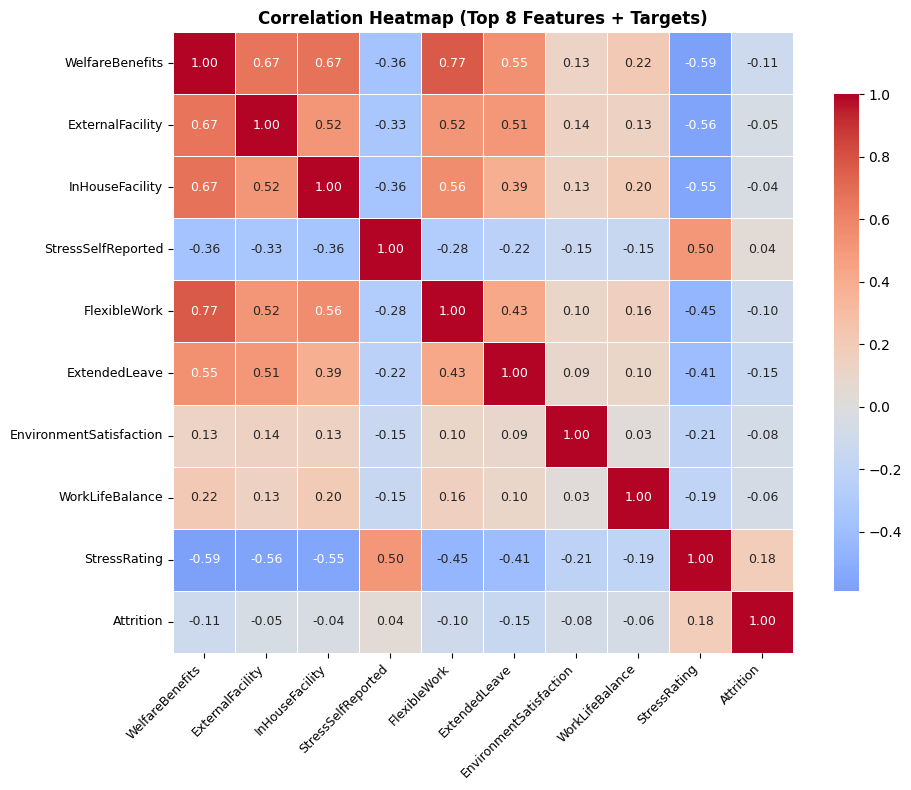

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

# Create correlation matrix (numeric features only)
correlation_matrix = processed_data.corr(numeric_only=True)

# Compute p-values (for reporting only)
p_value_matrix = pd.DataFrame(
    np.ones_like(correlation_matrix),
    index=correlation_matrix.index,
    columns=correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col_i = correlation_matrix.columns[i]
        col_j = correlation_matrix.columns[j]
        _, p_val = pearsonr(processed_data[col_i], processed_data[col_j])
        p_value_matrix.iloc[i, j] = p_val
        p_value_matrix.iloc[j, i] = p_val

# Analyze correlation with both targets
for target in targets:
    print(f"\n{'='*50}")
    print(f"Top correlations with {target}:")
    target_corr = correlation_matrix[target].drop(targets)
    top_5_corr = target_corr.abs().sort_values(ascending=False).head(5)
    for feat in top_5_corr.index:
        p_val_target = p_value_matrix.loc[feat, target]
        print(f"  - {feat}: r = {target_corr[feat]:.3f}, p = {p_val_target:.4g}")

# Select 8 important features by absolute correlation with StressRating
max_features = 8
target_corr = correlation_matrix['StressRating'].drop(targets)
important_features = target_corr.abs().sort_values(ascending=False).head(max_features).index.tolist()
selected_cols = important_features + targets

# Build subset matrix
corr_subset = correlation_matrix.loc[selected_cols, selected_cols]

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_subset,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9},
    xticklabels=True,
    yticklabels=True
)

plt.title(f'Correlation Heatmap (Top {len(important_features)} Features + Targets)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()